In [285]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt

In [286]:
n = 1000
X_train = torch.tensor(np.linspace(-10, 10, n), dtype=torch.float32)
y_train = torch.tensor(np.sin(X_train.numpy()) + np.random.normal(0, 0.2, X_train.shape), dtype=torch.float32)
X_test = torch.tensor(np.linspace(-10, 10, 100), dtype=torch.float32)
y_test = torch.tensor(np.sin(X_test.numpy()), dtype=torch.float32)
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

torch.Size([1000]) torch.Size([100]) torch.Size([1000]) torch.Size([100])


In [287]:
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10,10)
        self.fc3 = nn.Linear(10,1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

In [288]:
def train(model:nn.Module, device, criterion, train_dataloader: DataLoader, test_dataset, optimizer, epochs):
    loss = float("inf")
    losses = []
    accuracies = []
    model.to(device)
    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            batch_x = batch_x.reshape(-1,1)
            batch_y = batch_y.reshape(-1,1)
            # print(batch_x.shape)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            # print(batch_x.shape, batch_y.shape, outputs.shape)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            

        model.eval()
        with torch.no_grad():
            for batch_x, batch_y in test_dataset:
                batch_x, batch_y = batch_x.to(device).reshape(-1,1), batch_y.to(device).reshape(-1,1)
                testMSE = torch.Tensor(model(batch_x) - batch_y).square().mean().item()
                accuracies.append(testMSE)
                # print(batch_x.shape, model.parameters())
                if (epoch%25 ==0):
                    print(f"epoch: {epoch} loss: {loss.item()} test_mse: {testMSE}")
    

    fig, axis = plt.subplots(1, 2, figsize=(12, 4))
    axis[0].plot(losses)
    axis[0].set_title("loss")
    axis[0].plot(accuracies, color="red")

    axis[1].scatter(X, y, label="data")
    axis[1].scatter(X_test, model(X_test.to(device).reshape(-1,1)).detach().cpu(), label="model preds")
    
    plt.show()

In [289]:
model = NN()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
batch_size = len(X_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=0, persistent_workers=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
test_dataset = torch.Tensor(test_dataset)
criterion = nn.MSELoss()
epochs = 1000
optim = optim.Adam(model.parameters(), lr=1e-3)

cuda


epoch: 0 loss: 0.8149036765098572 test_mse: 0.7435232996940613
epoch: 25 loss: 0.5434155464172363 test_mse: 0.4892270267009735
epoch: 50 loss: 0.5087132453918457 test_mse: 0.46008697152137756
epoch: 75 loss: 0.5053743720054626 test_mse: 0.45730581879615784
epoch: 100 loss: 0.5033397078514099 test_mse: 0.4554477632045746
epoch: 125 loss: 0.5008506774902344 test_mse: 0.453196257352829
epoch: 150 loss: 0.498100221157074 test_mse: 0.45054975152015686
epoch: 175 loss: 0.49481630325317383 test_mse: 0.44738391041755676
epoch: 200 loss: 0.4907310903072357 test_mse: 0.4435286521911621
epoch: 225 loss: 0.485808789730072 test_mse: 0.43883228302001953
epoch: 250 loss: 0.4799520671367645 test_mse: 0.4332304000854492
epoch: 275 loss: 0.4728773534297943 test_mse: 0.42647218704223633
epoch: 300 loss: 0.4641190469264984 test_mse: 0.41810354590415955
epoch: 325 loss: 0.4527686834335327 test_mse: 0.4071747958660126
epoch: 350 loss: 0.43803268671035767 test_mse: 0.3930341899394989
epoch: 375 loss: 0.41612

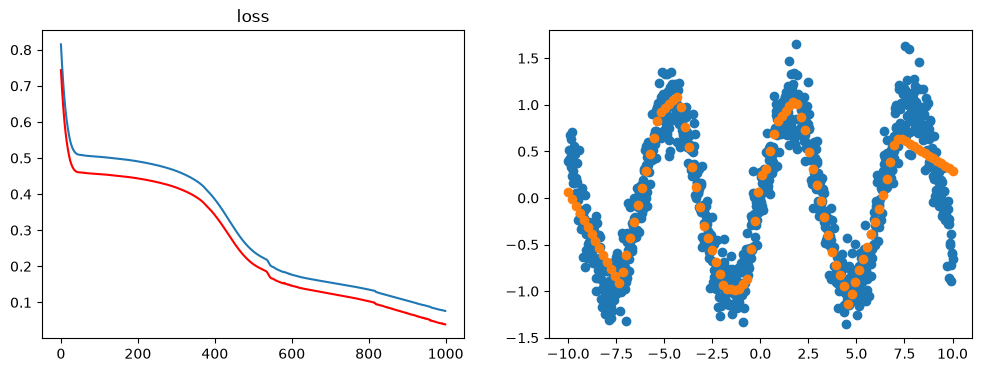

In [290]:
train(model, device, criterion, train_loader, test_loader, optim, epochs)